# Lesson 1: The Logic of Hypothesis Testing

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Translate a research question into a population parameter, null hypothesis, and alternative hypothesis
2. Explain p-values, significance levels, Type I errors, and Type II errors without common misconceptions
3. Connect hypothesis tests to confidence intervals and effect sizes
4. Distinguish statistical significance from practical significance


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 1.1 From a question to a testable claim

A useful hypothesis test begins with a **design**, not with a software menu.

| Question | Parameter | Typical null | Typical alternative |
|---|---:|---|---|
| Is a mean different from a target? | $\mu$ | $\mu=\mu_0$ | $\mu\ne\mu_0$ |
| Do two groups have different means? | $\mu_1-\mu_2$ | $\mu_1-\mu_2=0$ | $\mu_1-\mu_2\ne0$ |
| Did a conversion rate change? | $p_1-p_2$ | $p_1-p_2=0$ | $p_1-p_2\ne0$ |
| Are two categorical variables associated? | joint probabilities | independence | association |

The **null hypothesis** is a precise reference model. The **alternative** describes departures
that matter for the question. A two-sided alternative is the default unless direction was justified
before observing the data.


## 1.2 What a p-value is—and is not

A p-value is the probability, **assuming $H_0$ and the model assumptions are true**, of obtaining
a test statistic at least as incompatible with $H_0$ as the observed statistic.

It is **not**:

- the probability that $H_0$ is true;
- the probability the result happened "by chance";
- the size or importance of an effect;
- a guarantee that the result will replicate.

At level $\alpha$, reject $H_0$ when $p\le\alpha$. Otherwise, **fail to reject** $H_0$.
Failure to reject is not proof of no effect; it can reflect imprecision or low power.


Permutation-null rejection rate at alpha=.05: 0.050


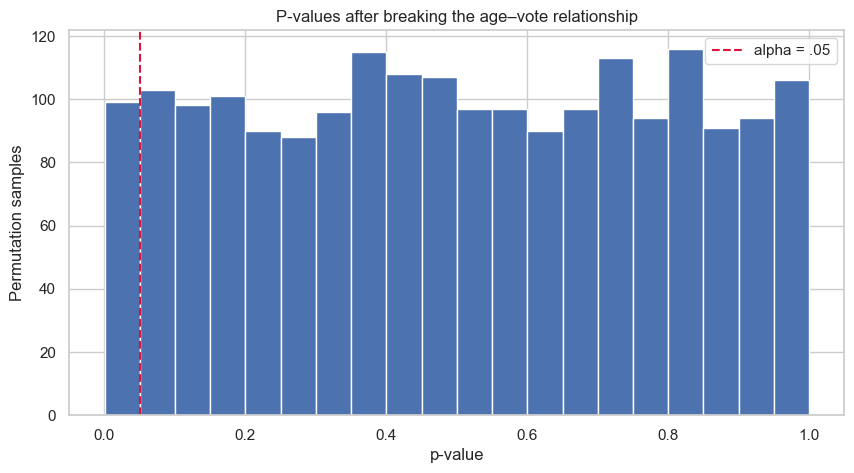

In [2]:
# Use real ANES ages and expected-vote labels to build a permutation null.
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
ages = anes["age_years"].to_numpy()
vote = anes["expected_vote"].to_numpy()
n_dole = np.sum(vote == "Dole")

p_values = []
for _ in range(2000):
    shuffled = rng.permutation(vote)
    dole_age = ages[shuffled == "Dole"]
    clinton_age = ages[shuffled == "Clinton"]
    p_values.append(stats.ttest_ind(dole_age, clinton_age, equal_var=False).pvalue)

p_values = np.asarray(p_values)
print(f"Permutation-null rejection rate at alpha=.05: {(p_values < .05).mean():.3f}")

fig, ax = plt.subplots()
ax.hist(p_values, bins=20, edgecolor="white")
ax.axvline(.05, color="crimson", linestyle="--", label="alpha = .05")
ax.set(xlabel="p-value", ylabel="Permutation samples",
       title="P-values after breaking the age–vote relationship")
ax.legend()
plt.show()


## 1.3 Test statistics, confidence intervals, and effect sizes

Most test statistics have the form

$$\text{signal-to-noise} = \frac{\text{estimate}-\text{null value}}{\text{standard error}}.$$

A compatible confidence interval answers a richer question: which parameter values remain plausible?
For a two-sided test at $\alpha=.05$, a 95% confidence interval that excludes the null value leads to
rejection at the same level. Always pair the test with an effect size in the outcome's natural units.


In [3]:
# One-sample example using respondents' real ages.
sample = anes["age_years"].dropna().to_numpy()
null_mean = 45
result = stats.ttest_1samp(sample, popmean=null_mean)
estimate = sample.mean()
se = sample.std(ddof=1) / np.sqrt(len(sample))
ci = stats.t.interval(.95, df=len(sample)-1, loc=estimate, scale=se)
d = (estimate-null_mean) / sample.std(ddof=1)

pd.Series({"sample mean age": estimate, "mean difference from 45": estimate-null_mean,
           "95% CI low": ci[0], "95% CI high": ci[1], "t": result.statistic,
           "p": result.pvalue, "Cohen d": d, "n": len(sample)})


sample mean age             47.0434
mean difference from 45      2.0434
95% CI low                  45.9944
95% CI high                 48.0924
t                            3.8229
p                            0.0001
Cohen d                      0.1244
n                          944.0000
dtype: float64

## Worked example and interpretation

### What the analysis does

The first calculation uses 944 ANES respondents and separates their ages by expected vote. It repeatedly shuffles the vote labels while keeping the observed ages fixed, then recomputes a two-group test. This destroys the age–vote association and creates a reference distribution for a null world. In 2,000 shuffled datasets, about 5.0% of the resulting p-values fell below the preselected 0.05 threshold. That is the expected long-run false-rejection behavior under this particular permutation setup, not the probability that a particular null hypothesis is true.

### What the result means

A second calculation compares the respondents' mean age, 47.04 years, with a teaching benchmark of 45 years. The estimated difference is 2.04 years; the 95% confidence interval for the mean age is 45.99 to 48.09, and Cohen's d is 0.124. The small p-value reflects high precision with 944 observations, while the standardized difference is small. The benchmark was chosen for instruction, so this result does not establish an important real-world age threshold. Both analyses illustrate why the design, reference model, magnitude, and interval must be read together.

## Practice and solution

**Practice.** A result has $p=.08$ and a 95% CI for the mean difference of $[-0.4, 6.2]$.
What can you conclude?

<details><summary>Solution</summary>

At alpha = .05, fail to reject a two-sided null of zero difference because the interval includes zero.
The data are compatible with a small negative effect through a moderately positive effect, so the
estimate is too imprecise to conclude either "no effect" or a clearly useful benefit.
</details>

## Key takeaways

1. Begin with the estimand and design.
2. A p-value measures compatibility with a null model, not truth or importance.
3. Confidence intervals and effect sizes carry information a binary decision discards.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
